This notebook is meant for developing/testing code related to the blazar-DESI cross-correlation project

In [1]:
from astropy.coordinates import SkyCoord
from astropy.table import Table 
import matplotlib.pyplot as plt
from astropy import units as u 
from astropy.io import fits
from tqdm import tqdm 
from glob import glob
import healpy as hp 
import numpy as np
import scipy

In [2]:
# Just a test..
#from compute_wtheta import compute_wtheta
#compute_wtheta('4LAC_DR3_FSRQ.fits', 20, '', sample2 = '4LAC_DR3_BLL.fits')

In [2]:
def sky_plotter(fits_file, nside):
    fname = fits_file.split('.')[0]
    data = fits.open(fits_file)[1].data
    ra = data['ra']
    dec = data['dec']
    
    gal_coords = np.empty((len(ra), 2))
    icrs_coords = SkyCoord(ra = ra * u.degree, dec = dec * u.degree, frame = 'icrs')
    gal_coords[:, 0] = icrs_coords.galactic.l.to(u.deg).value
    gal_coords[:, 1] = icrs_coords.galactic.b.to(u.deg).value
    np.save(fname + "_gal_coords.npy", gal_coords)
    
    pix = hp.pixelfunc.ang2pix(nside, gal_coords[:, 0], gal_coords[:, 1], lonlat = True)
    npix = hp.nside2npix(nside)
    map_ = np.zeros(npix)
    map_.dtype = 'int'
    map_[pix] = int(1)
    hp.mollview(map_, title = fname, coord = 'G')
    #hp.fitsfunc.write_map(fname + '_map.fits', map_, coord = 'G', overwrite = True)

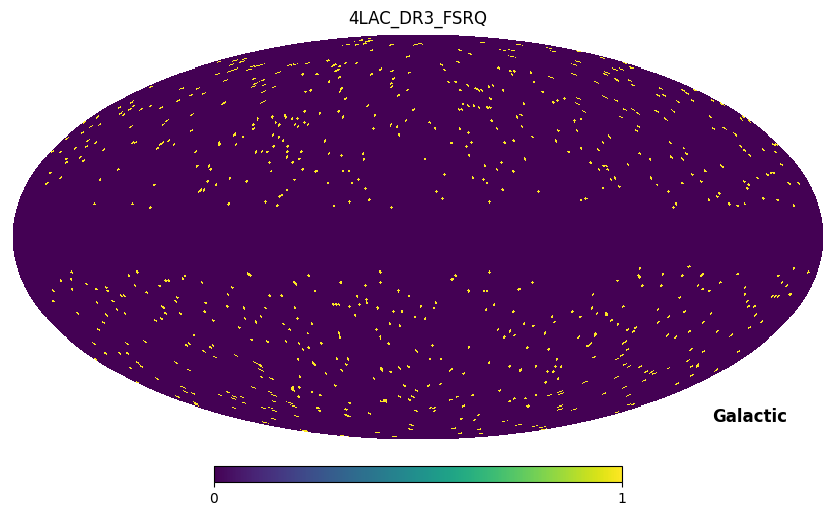

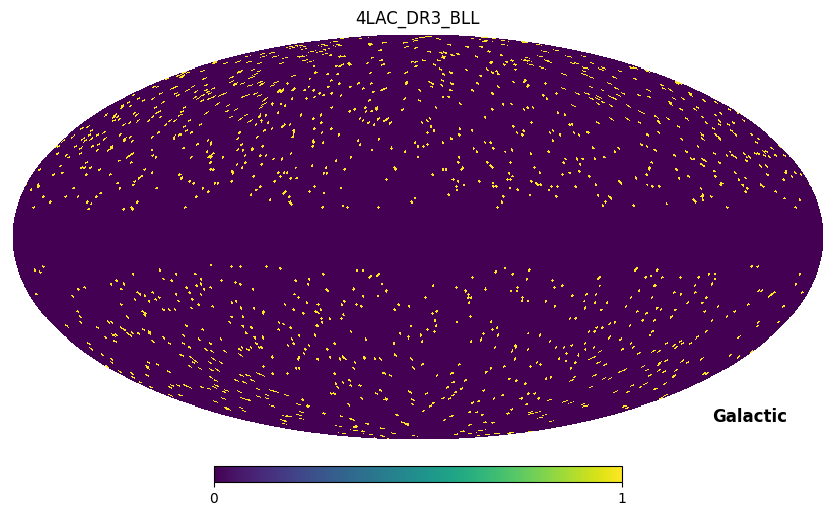

In [3]:
sky_plotter('4LAC_DR3_FSRQ.fits', 64)
sky_plotter('4LAC_DR3_BLL.fits', 64)

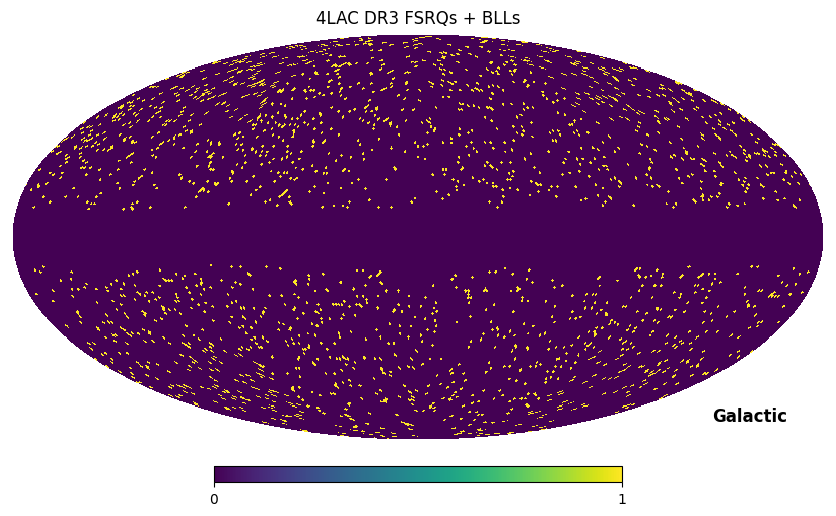

In [15]:
fsrq_map = hp.read_map('4LAC_DR3_FSRQ_map.fits')
bll_map = hp.read_map('4LAC_DR3_BLL_map.fits')
hp.mollview(fsrq_map | bll_map, title = '4LAC DR3 FSRQs + BLLs', coord = 'G')

In [5]:
fsrq_gal_coords = np.load("4LAC_DR3_FSRQ_gal_coords.npy")
bll_gal_coords = np.load("4LAC_DR3_BLL_gal_coords.npy")
coords = np.concatenate((fsrq_gal_coords, bll_gal_coords))

(360.0, 0.0)

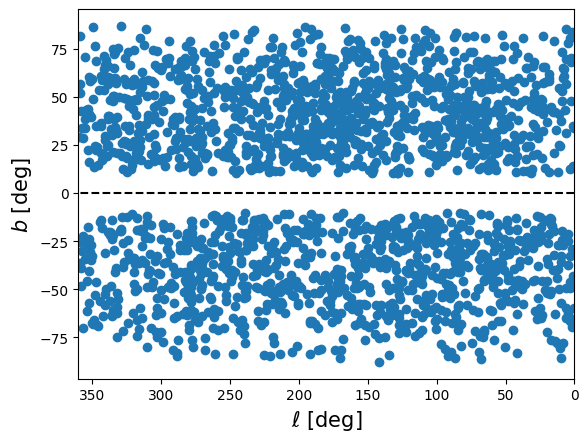

In [6]:
plt.scatter(coords[:, 0], coords[:, 1])
center = np.zeros((5, 2))
center[:, 0] = np.linspace(0., 360., 5)
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

In [51]:
min_dist_arr = []

for p1 in center:
    min_dist = np.inf
    
    for p2 in tqdm(coords):
        dist =  np.sqrt(((p1[0] - p2[0]) ** 2) + ((p1[1] - p2[1]) ** 2))

        if dist < min_dist:
            min_dist = dist 
        
    min_dist_arr.append(min_dist)

100%|██████████| 2134/2134 [00:00<00:00, 389666.73it/s]


In [52]:
dist = round(min(min_dist_arr))
print(dist)

11


(360.0, 0.0)

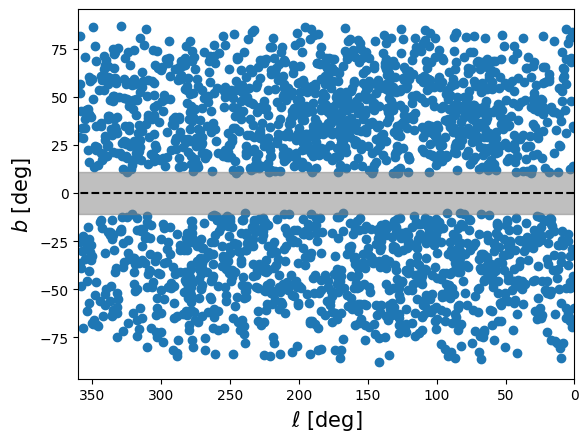

In [53]:
plt.scatter(coords[:, 0], coords[:, 1])
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.fill_between(center[:, 0], np.ones((len(center),)) * (-dist), np.ones((len(center),)) * dist, alpha = 0.5, color = 'grey')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

In [56]:
min_l = min(coords[:, 0])
print('min l:', min_l)
max_l = max(coords[:, 0])
print('max l:', max_l)
min_b = min(coords[:, 1])
print('min b:', min_b)
max_b = max(coords[:, 1])
print('max b:', max_b)

min l: 0.1552646831622595
max l: 359.90082249798337
min b: -87.68008956731327
max b: 86.76989229909942


In [63]:
randoms = np.empty((1380 * 50, 2)) # 50 times as many randoms as BLLs. For simplicity, we generate randoms from the union of both catalogues
n_success = 0 

while n_success < 1380 * 50:
    sin_p1 = np.random.uniform(-1, 1, 1)
    p1 = (np.arcsin(sin_p1) * 180 / np.pi)[0] 

    if (min_b < p1 < -dist) or (dist < p1 < max_b):
        p0 = np.random.uniform(0., 360., 1)[0]

        if min_l < p0 < max_l:
            randoms[n_success, 0] = p0
            randoms[n_success, 1] = p1
            n_success += 1

(360.0, 0.0)

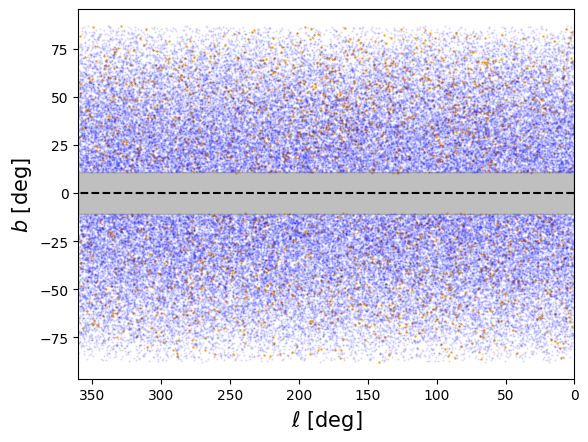

In [64]:
plt.scatter(coords[:, 0], coords[:, 1], s = 0.5, color = 'orange')
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.fill_between(center[:, 0], np.ones((len(center),)) * (-dist), np.ones((len(center),)) * dist, alpha = 0.5, color = 'grey')
plt.scatter(randoms[:, 0], randoms[:, 1], s = 0.5, alpha = 0.1, color = 'blue')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

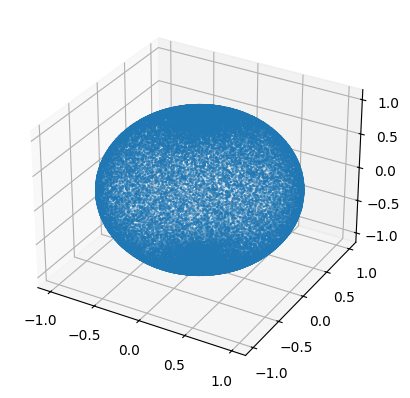

In [66]:
r = 1.
x = r * np.sin(randoms[:, 0]) * np.cos(randoms[:, 1])
y = r * np.sin(randoms[:, 0]) * np.sin(randoms[:, 1])
z = r * np.cos(randoms[:, 0])

fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.scatter(x, y, z, s = 0.1)

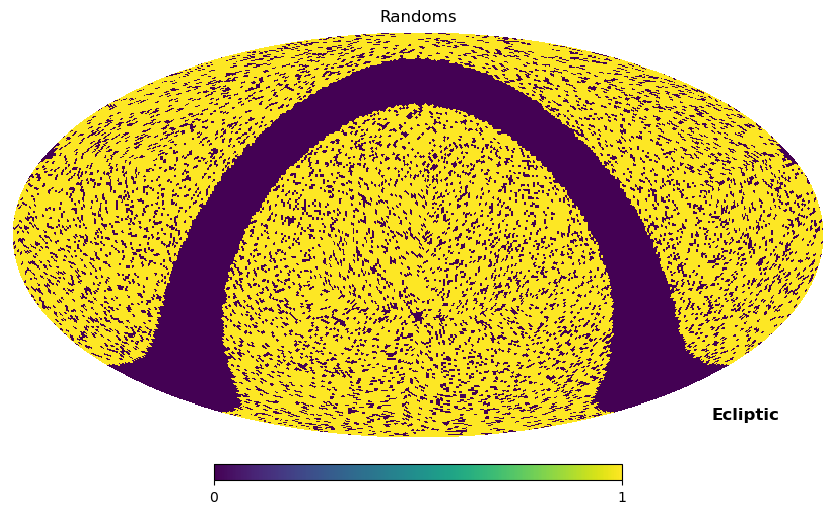

In [52]:
nside = 64
pix = hp.pixelfunc.ang2pix(nside, randoms[:, 0], randoms[:, 1], lonlat = True)
npix = hp.nside2npix(nside)
map_ = np.zeros(npix)
map_.dtype = 'int'
map_[pix] = int(1)
hp.mollview(map_, title = 'Randoms', coord = 'GE') # Appears uniform over the sphere! 
#plt.savefig('randoms.png', dpi = 400, bbox_inches = 'tight')

In [15]:
randoms_ = np.empty(randoms.shape)
gal_coords = SkyCoord(l = randoms[:, 0] * u.degree, b = randoms[:, 1] * u.degree, frame = 'galactic')
randoms_[:, 0] = gal_coords.icrs.ra.to(u.deg).value # Convert back to RA and Dec for pycorr 
randoms_[:, 1] = gal_coords.icrs.dec.to(u.deg).value

In [54]:
rand_t = Table()
rand_t['ra'] = randoms_[:, 0]
rand_t['dec'] = randoms_[:, 1]
rand_t.write('randoms.fits', format = 'fits', overwrite = True)

Moving on to correlation functions...

In [12]:
wtheta_fsrq = np.load('wtheta_fsrq.npy', allow_pickle = True).ravel()[0]
wtheta_bll = np.load('wtheta_bll.npy', allow_pickle = True).ravel()[0]
wtheta_cross = np.load('wtheta_cross.npy', allow_pickle = True).ravel()[0]

In [18]:
wtheta_cross.

array([ 6.75, 10.25, 13.75, 17.25, 20.75, 24.25, 27.75, 31.25, 34.75,
       38.25])

In [13]:
def wtheta_dvecs(pycorr_jk_obj):
    sep = pycorr_jk_obj.sep[1:] # For some reason the 1st data point is always weird with pycorr
    wtheta = pycorr_jk_obj.corr[1:]
    dvecs = []

    for i in pycorr_jk_obj.realizations:
        dvecs.append(pycorr_jk_obj.realization(i).corr[1:])

    cov = np.cov(dvecs, rowvar = False, bias = True) * (len(pycorr_jk_obj.realizations) - 1)
    err = np.sqrt(cov.diagonal())

    res = np.empty((len(sep),3))
    res[:, 0] = sep
    res[:, 1] = wtheta
    res[:, 2] = err

    return res 

In [14]:
fsrq_arr = wtheta_dvecs(wtheta_fsrq)
bll_arr = wtheta_dvecs(wtheta_bll)
cross_arr = wtheta_dvecs(wtheta_cross)

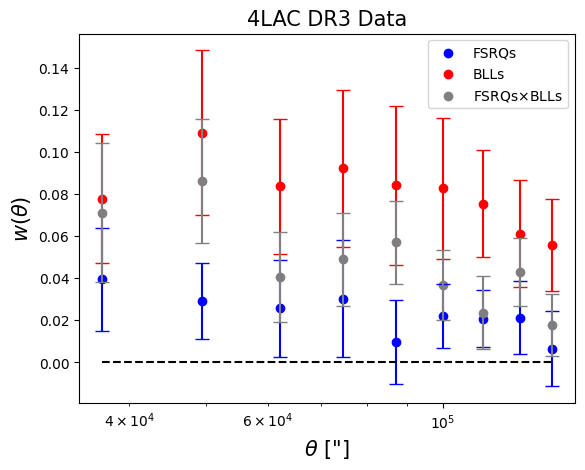

In [5]:
plt.scatter(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'red', label = 'BLLs')
plt.errorbar(bll_arr[:, 0] * 3600, bll_arr[:, 1], yerr = bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.scatter(cross_arr[:, 0] * 3600, cross_arr[:, 1], color = 'grey', label = 'FSRQs' + r'$\times$' + 'BLLs')
plt.errorbar(cross_arr[:, 0] * 3600, cross_arr[:, 1], yerr = cross_arr[:, 2], linestyle = '', capsize = 5, color = 'grey')
plt.hlines(0, min(fsrq_arr[:, 0] * 3600), max(fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('4LAC DR3 Data', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')
plt.savefig('4LAC_DR3_wtheta.png', dpi = 400, bbox_inches = 'tight')

In [6]:
wp_desi = np.load('wp_desi.npy', allow_pickle = True).ravel()[0]

In [7]:
sep = wp_desi.sep[1:, 0]
wp = wp_desi(pimax = 100.)[1:]

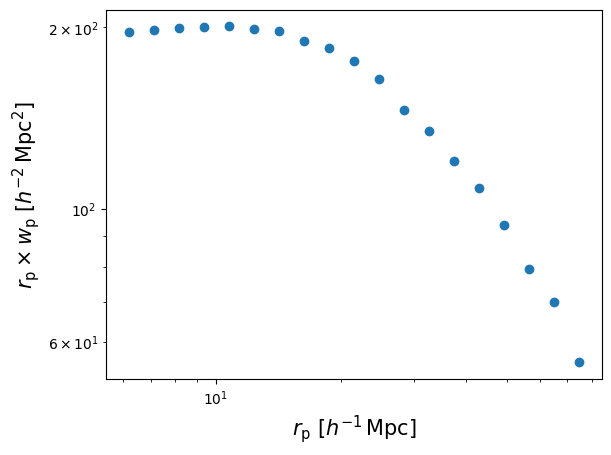

In [25]:
plt.scatter(sep, wp * sep)
plt.xlabel(r'$r_{\mathrm{p}}\,\,[h^{-1}\,\mathrm{Mpc}]$', fontsize = 15)
plt.ylabel(r'$r_{\mathrm{p}}\times w_{\mathrm{p}}\,\,[h^{-2}\,\mathrm{Mpc}^2]$', fontsize = 15)
plt.xscale('log')
plt.yscale('log')

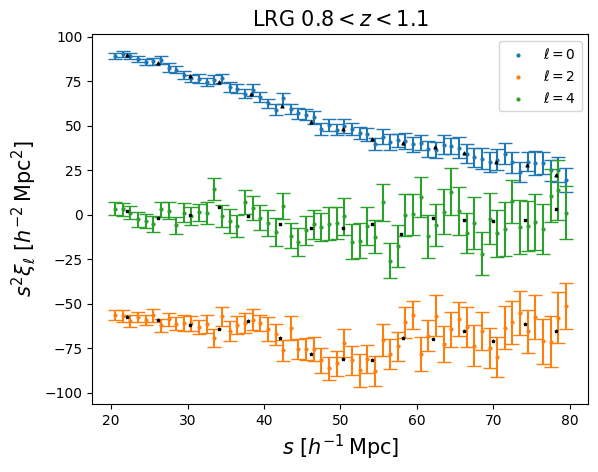

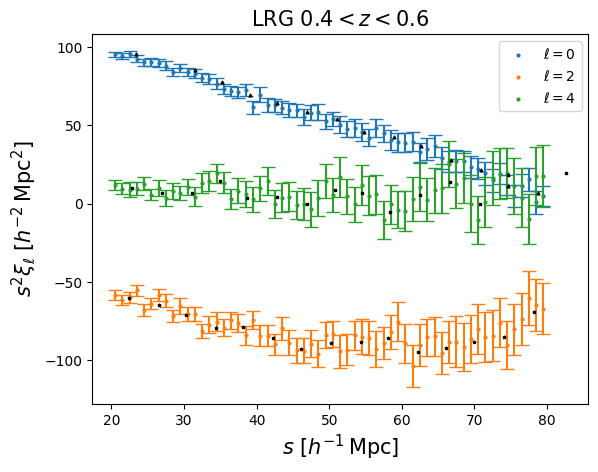

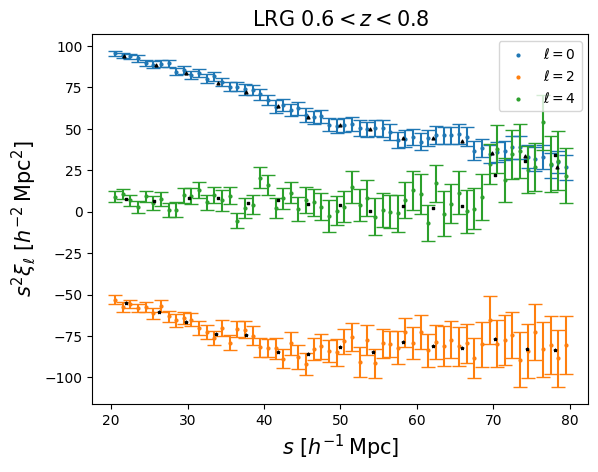

In [51]:
files = glob('eta_z*.npy')
z_bin_dict = {'z1':[0.4, 0.6], 'z2':[0.6, 0.8], 'z3':[0.8, 1.1]}
mu_midpts = (np.linspace(-1, 1, 200)[1:] + np.linspace(-1, 1, 200)[:-1]) / 2
dx = mu_midpts[1] - mu_midpts[0]
L2 = 0.5 * ((3 * (mu_midpts ** 2)) -1) # 2nd degree Legendre polynomial 
L4 = (1 / 8) * ((35 * (mu_midpts ** 4)) - (30 * (mu_midpts ** 2)) + 3) # 4th degree 

for f in files:
    z_bin = f.split('_')[-1].replace('.npy', '')
    bin_edges = z_bin_dict[z_bin]
    eta = np.load(f, allow_pickle = True).ravel()[0]
    
    ell_0 = 0.5 * np.sum(eta.corr * dx, axis = 1)
    ell_2 = 2.5 * np.sum(eta.corr * L2 * dx, axis = 1)
    ell_4 = 4.5 * np.sum(eta.corr * L4 * dx, axis = 1)

    dvecs = np.empty((len(eta.realizations), len(ell_0), 3)) # Each column is a different variable 

    for i in eta.realizations:
        corr = eta.realization(i).corr 
        ell_0_ = 0.5 * np.sum(corr * dx, axis = 1)
        ell_2_ = 2.5 * np.sum(corr * L2 * dx, axis = 1)
        ell_4_ = 4.5 * np.sum(corr * L4 * dx, axis = 1)

        dvecs[i, :, 0] = ell_0_
        dvecs[i, :, 1] = ell_2_
        dvecs[i, :, 2] = ell_4_
    
    err_0 = np.sqrt((np.cov(dvecs[:, :, 0], rowvar = False, bias = True) * (len(eta.realizations) - 1)).diagonal())
    err_2 = np.sqrt((np.cov(dvecs[:, :, 1], rowvar = False, bias = True) * (len(eta.realizations) - 1)).diagonal())
    err_4 = np.sqrt((np.cov(dvecs[:, :, 2], rowvar = False, bias = True) * (len(eta.realizations) - 1)).diagonal())

    desi_0 = np.loadtxt('desi_' + z_bin + '_0.txt', delimiter = ',')
    desi_2 = np.loadtxt('desi_' + z_bin + '_2.txt', delimiter = ',')
    desi_4 = np.loadtxt('desi_' + z_bin + '_4.txt', delimiter = ',')

    plt.scatter(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_0, label = r'$\ell=0$', s = 4)
    plt.errorbar(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_0, yerr = (eta.sep[:, 0] ** 2) * err_0, linestyle = '', capsize = 5)
    plt.scatter(desi_0[:, 0], desi_0[:, 1], s = 4, marker = '^', color = 'k', zorder = 100)
    plt.scatter(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_2, label = r'$\ell=2$', s = 4)
    plt.errorbar(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_2, yerr = (eta.sep[:, 0] ** 2) * err_2, linestyle = '', capsize = 5)
    plt.scatter(desi_2[:, 0], desi_2[:, 1], s = 4, marker = 's', color = 'k', zorder = 101)
    plt.scatter(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_4, label = r'$\ell=4$', s = 4)
    plt.errorbar(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_4, yerr = (eta.sep[:, 0] ** 2) * err_4, linestyle = '', capsize = 5)
    plt.scatter(desi_4[:, 0], desi_4[:, 1], s = 4, marker = '*', color = 'k', zorder = 102)
    plt.title('LRG ' + str(bin_edges[0]) + r'$<z<$' + str(bin_edges[1]), fontsize = 15)
    plt.xlabel(r'$s\,\,[h^{-1}\,\mathrm{Mpc}]$', fontsize = 15)
    plt.ylabel(r'$s^2\xi_\ell\,\,[h^{-2}\,\mathrm{Mpc}^2]$', fontsize = 15)
    plt.legend(loc = 'best')
    plt.savefig('desi_lrg_' + z_bin + '.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

Now, we want to test if the differences between $w(\theta)$ are because of the randoms or the samples themselves. So, we will downsample one to match the density of the other...

In [98]:
fsrq = fits.open('4LAC_DR3_FSRQ.fits')[1].data
bll = fits.open('4LAC_DR3_BLL.fits')[1].data
dict_ = {'fsrq': len(fsrq['ra']), 'bll': len(bll['ra'])}
larger_idx = list(dict_.values()).index(max(dict_.values()))
larger_samp = list(dict_.keys())[larger_idx]
larger_samp 

'bll'

Therefore we downsample BLL objects...

In [99]:
indices_to_keep = np.random.choice(dict_['bll'], size = dict_['fsrq'], replace = False)
t = Table()
t['ra'] = bll['ra'][indices_to_keep]
t['dec'] = bll['dec'][indices_to_keep]
t['flags'] = bll['flags'][indices_to_keep]
t['class'] = bll['class'][indices_to_keep]
t['z'] = bll['z'][indices_to_keep]

print(len(t) == len(fsrq['ra']))
t.write('4LAC_DR3_downsampled_BLL.fits', format = 'fits', overwrite = True)

True


In [101]:
from compute_wtheta import compute_wtheta
res = compute_wtheta('4LAC_DR3_downsampled_BLL.fits', 20, 'wtheta_downsampled_bll')

In [8]:
wtheta_downsampled_bll = np.load('wtheta_downsampled_bll.npy', allow_pickle = True).ravel()[0]

In [9]:
downsampled_bll_arr = wtheta_dvecs(wtheta_downsampled_bll)

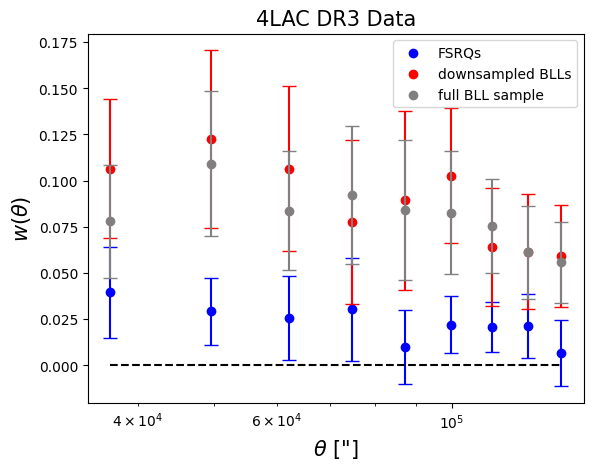

In [10]:
plt.scatter(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(downsampled_bll_arr[:, 0] * 3600, downsampled_bll_arr[:, 1], color = 'red', label = 'downsampled BLLs')
plt.errorbar(downsampled_bll_arr[:, 0] * 3600, downsampled_bll_arr[:, 1], yerr = downsampled_bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.scatter(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'grey', label = 'full BLL sample')
plt.errorbar(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'grey', yerr = bll_arr[:, 2], linestyle = '', capsize = 5)
plt.hlines(0, min(fsrq_arr[:, 0] * 3600), max(fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('4LAC DR3 Data', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')

In [22]:
data = fits.open('DESI_DR1_LRG.fits')[1].data
ra = data['ra']
dec = data['dec']

(360.0, 0.0)

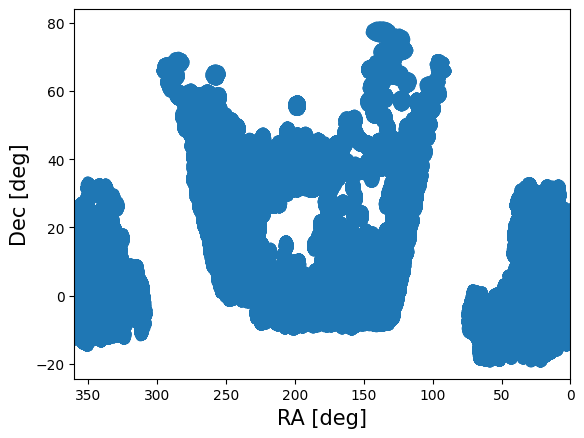

In [23]:
plt.scatter(ra, dec)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

Can make a simple declination cut to make pair counts faster. 

setting the output map dtype to [dtype('int64')]


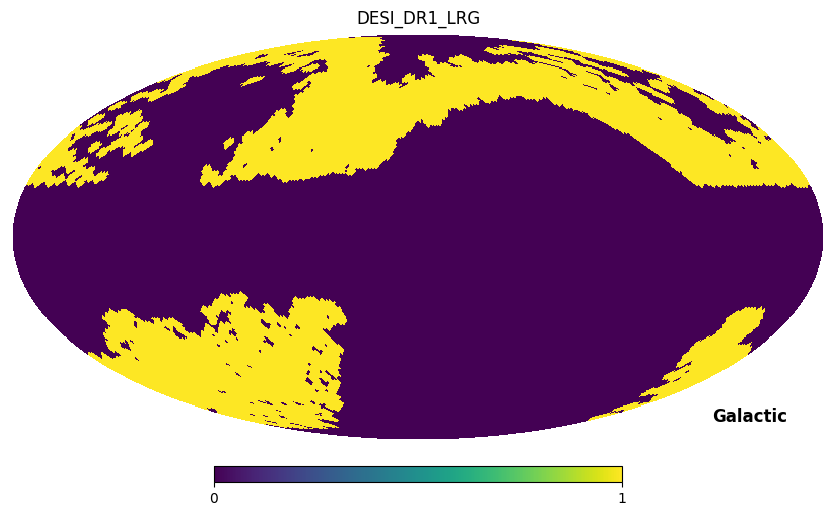

In [14]:
sky_plotter('DESI_DR1_LRG.fits', 64)

In [16]:
desi_map = hp.read_map('DESI_DR1_LRG_map.fits')

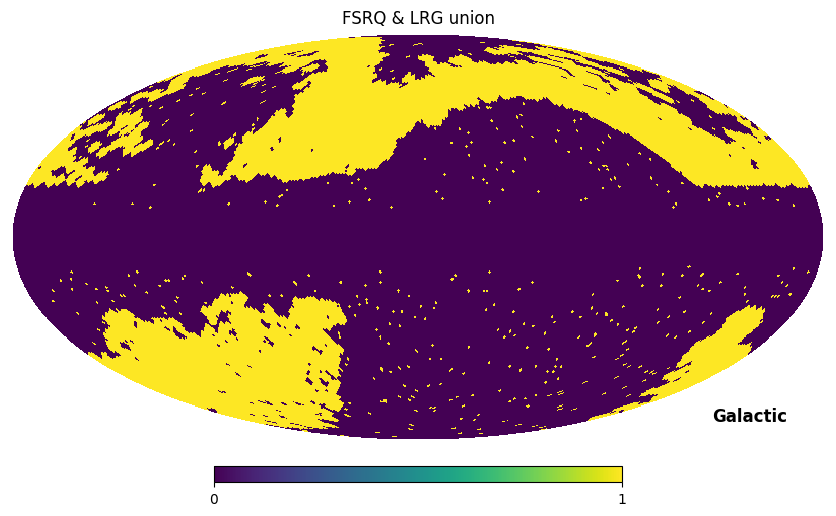

In [20]:
hp.mollview(fsrq_map | desi_map, title = 'FSRQ & LRG union', coord = 'G')

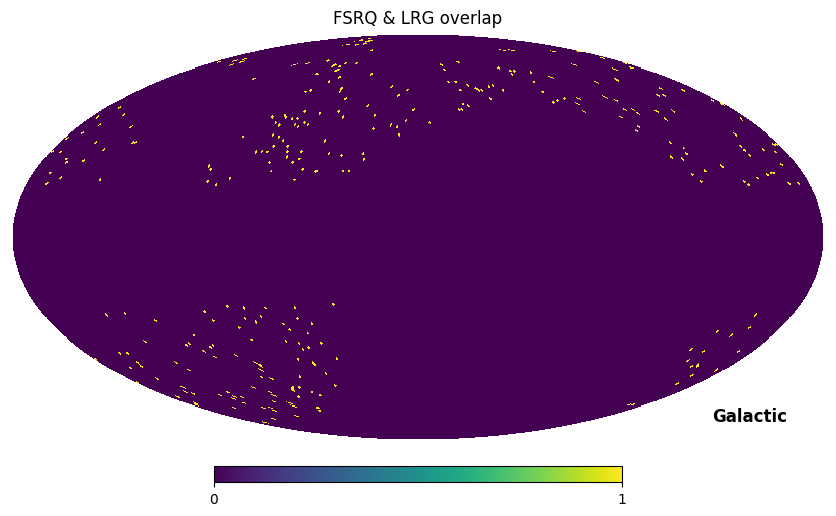

In [19]:
hp.mollview(fsrq_map & desi_map, title = 'FSRQ & LRG overlap', coord = 'G')

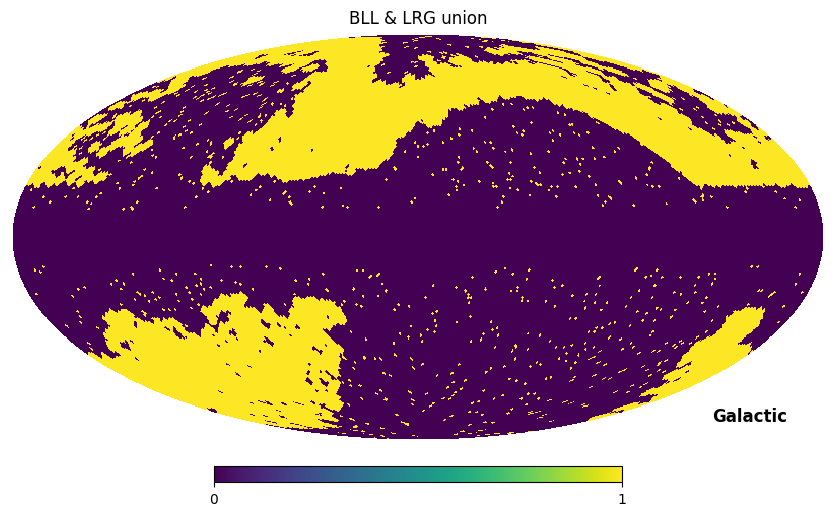

In [18]:
hp.mollview(bll_map | desi_map, title = 'BLL & LRG union', coord = 'G')

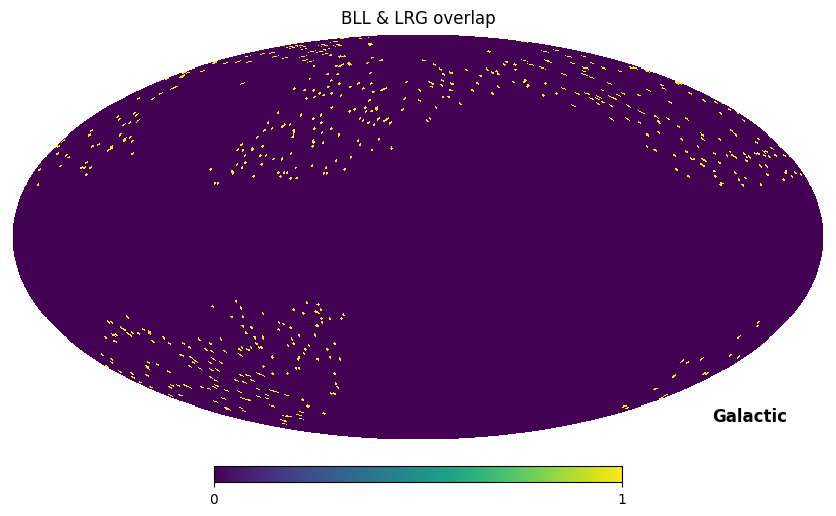

In [21]:
hp.mollview(bll_map & desi_map, title = 'BLL & LRG overlap', coord = 'G')

In [4]:
#fsrq_desi_obj = np.load('fsrq_desi_obj.npy', allow_pickle = True).ravel()[0]
#bll_desi_obj = np.load('fsrq_bll_obj.npy', allow_pickle = True).ravel()[0]
#dict_ = {'FSRQ':fsrq_desi_obj, 'BLL':bll_desi_obj}
N_gals = len(fits.open('DESI_DR1_LRG.fits')[1].data['ra'])
print(N_gals)
N_rands = N_gals * 40
print(N_rands)

2138627
85545080


In [ ]:
for label, obj in zip(dict_.keys(), dict_.values()):
    D1D2 = obj.D1D2.ncounts
    D1R2 = obj.D1R2.ncounts 

    wtheta_cross = ((N_rands / N_gals) * D1D2 / D1R2) - 1
    theta = obj.sep / 3600

    plt.scatter(theta, wtheta_cross, label = label)
    plt.xlabel(r'$\theta\,\,["]$', fontsize = 15)
    plt.ylabel('$w(\theta)$', fontsize = 15)
    plt.legend(loc = 'best')

In [114]:
# Playing around with the LAT detection threshold file...
hdul = fits.open('detthresh_P8R3_12years_PL22.fits')

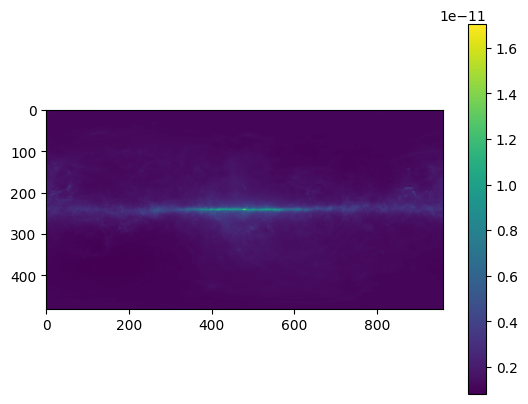

In [115]:
plt.imshow(hdul[0].data)
plt.colorbar()
plt.savefig('detec_thresh.png', dpi = 400, bbox_inches = 'tight')

The above appears to be the correct map...

In [116]:
hdul[0].data.shape 

(481, 960)

In [117]:
max(hdul[0].data.flatten())

np.float32(1.702619e-11)

In [118]:
hdul.info()

Filename: detthresh_P8R3_12years_PL22.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (960, 481)   float32   


Galactic latitude goes from 0 to 360, and longitude from 90 to -90. Each pixel therefore must represent a bin.

In [119]:
lat_bins = np.linspace(0, 360, num = hdul[0].data.shape[-1] + 1)
long_bins = np.linspace(-90, 90, num = hdul[0].data.shape[0] + 1)
lat_bins[:10]

array([0.   , 0.375, 0.75 , 1.125, 1.5  , 1.875, 2.25 , 2.625, 3.   ,
       3.375])

In [120]:
x_pix = np.arange(0, hdul[0].data.shape[-1], 1)
y_pix = np.arange(0, hdul[0].data.shape[0], 1)
x_pix[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Code below assigns a detection threshold to a given lat, long coordinate

In [9]:
hdul = fits.open('detthresh_P8R3_12years_PL22.fits')
lat_bins = np.linspace(0, 360, num = hdul[0].data.shape[-1] + 1)
long_bins = np.linspace(-90, 90, num = hdul[0].data.shape[0] + 1)
x_pix = np.arange(0, hdul[0].data.shape[-1], 1)
y_pix = np.arange(0, hdul[0].data.shape[0], 1)

def assign_thresh(lat, long):
    if (0 <= lat <= 360) and (-90 <= long <= 90):
        default_lat_bin = [-1000, -999]
        default_long_bin = [-1000, -999]
        i = 0
        j = 0 

        while (default_lat_bin[0] <= lat <= default_lat_bin[1]) == False:
            default_lat_bin = [lat_bins[i], lat_bins[i + 1]]
            i += 1

        while (default_long_bin[0] <= long <= default_long_bin[1]) == False:
            default_long_bin = [long_bins[j], long_bins[j + 1]]
            j += 1

        x = x_pix[i - 1]
        y = y_pix[j - 1]
        flux = hdul[0].data[y, x]

        return flux 

    else:
        print('reformat')

Below, we test the function above to make sure it behaves as expected...

In [122]:
assign_flux(0, -90)

0
0
1.0748457e-12


np.float32(1.0748457e-12)

In [123]:
assign_flux(0, 90)

0
480
1.0053599e-12


np.float32(1.0053599e-12)

In [124]:
assign_flux(360, 90)

959
480
1.0052548e-12


np.float32(1.0052548e-12)

In [125]:
assign_flux(360, -90)

959
0
1.0748346e-12


np.float32(1.0748346e-12)

In [126]:
# Now, try something near the middle, where the flux threshold is highest, and compare to the cbar
assign_flux(180, 0)

479
240
1.6185872e-11


np.float32(1.6185872e-11)

Looks good! 

In [11]:
blazar_cat = fits.open('table-4LAC-DR3-h.fits')[1].data
blazar_cat.columns

ColDefs(
    name = 'Source_Name'; format = '18A'
    name = 'DataRelease'; format = 'I'; null = 16959
    name = 'RAJ2000'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'DEJ2000'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'GLON'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'GLAT'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'Signif_Avg'; format = 'E'; disp = 'F8.3'
    name = 'Flux1000'; format = 'E'; unit = 'ph cm-2 s-1'; disp = 'E10.4'
    name = 'Unc_Flux1000'; format = 'E'; unit = 'ph cm-2 s-1'; disp = 'E10.4'
    name = 'Energy_Flux100'; format = 'E'; unit = 'erg cm-2 s-1'; disp = 'E10.4'
    name = 'Unc_Energy_Flux100'; format = 'E'; unit = 'erg cm-2 s-1'; disp = 'E10.4'
    name = 'SpectrumType'; format = '18A'
    name = 'PL_Index'; format = 'E'; disp = 'F8.4'
    name = 'Unc_PL_Index'; format = 'E'; disp = 'F8.4'
    name = 'Pivot_Energy'; format = 'E'; unit = 'MeV'; disp = 'F10.2'
    name = 'LP_Index'; format = 'E'; disp = 'F8.4'
    nam

In [12]:
blazar_cat = fits.open('table-4LAC-DR3-h.fits')[1].data

def create_randoms(sample): # Should potentially implement multiprocessing depending on size of cat. For now, okay...
    '''
    Only meant for use with FSRQs and BLLs 
    '''
    
    if sample == 'fsrq':
        indices = np.where(blazar_cat['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_cat['CLASS'] == 'FSRQ')[0].tolist()
        
    if sample == 'bll': 
        indices = np.where(blazar_cat['CLASS'] == 'bll')[0].tolist() + np.where(blazar_cat['CLASS'] == 'BLL')[0].tolist()

    fluxes = blazar_cat['Energy_Flux100'][indices]
    nrands = 0
    rand_pos = np.empty((40 * len(fluxes),3))

    while nrands < 40 * len(fluxes):
        flux = np.random.choice(fluxes, size = 1)
        sin_long = np.random.uniform(-1., 1., 1)
        long = (np.arcsin(sin_long) * 180 / np.pi)[0] 
        
        if abs(long) > 10:
            lat = np.random.uniform(0., 360., 1)[0]
            thresh = assign_thresh(lat, long)

            if flux > thresh: 
                #print('success')
                gal_coords = SkyCoord(l = lat * u.degree, b = long * u.degree, frame = 'galactic')
                dec = gal_coords.icrs.dec.to(u.deg).value
                rand_pos[nrands:, 0] = gal_coords.icrs.ra.to(u.deg).value
                rand_pos[nrands:, 1] = dec
                rand_pos[nrands:, 2] = flux
                nrands += 1

            #else:
            #    print('failed flux') # Just for debugging 

    return rand_pos  

In [13]:
fsrq_rands = create_randoms('fsrq')

In [14]:
np.save('good_fsrq_randoms.npy', fsrq_rands)

In [15]:
bll_rands = create_randoms('bll')

In [16]:
np.save('good_bll_randoms.npy', bll_rands)

None are failing with the fluxes they get... maybe we are using the wrong fluxes? (FIXED)

(0.0, 7.5e-11)

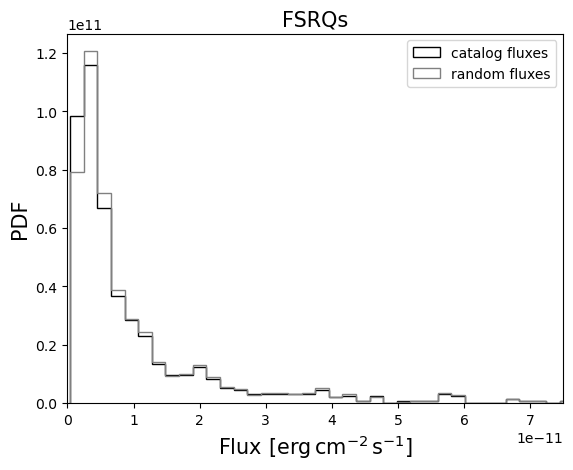

In [19]:
indices = np.where(blazar_cat['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_cat['CLASS'] == 'FSRQ')[0].tolist()
cat_fluxes = blazar_cat['Energy_Flux100'][indices]

freq, bins, _ = plt.hist(cat_fluxes, bins = 'fd', density = True, color = 'k', histtype = 'step', label = 'catalog fluxes')
plt.hist(fsrq_rands[:, -1], bins = bins, density = True, color = 'grey', histtype = 'step', label = 'random fluxes')
plt.title('FSRQs', fontsize = 15)
plt.xlabel('Flux' + r'$\,\,[\mathrm{erg\,cm^{-2}\,s^{-1}}]$', fontsize = 15)
plt.ylabel('PDF', fontsize = 15)
plt.legend(loc = 'best')
plt.xlim(0, 0.75e-10)

(0.0, 3e-11)

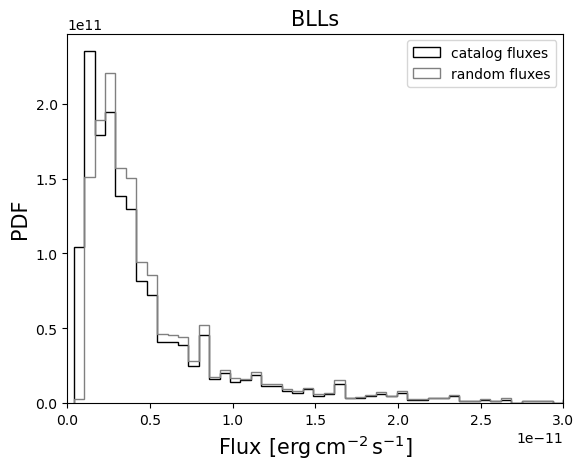

In [23]:
indices = np.where(blazar_cat['CLASS'] == 'bll')[0].tolist() + np.where(blazar_cat['CLASS'] == 'bll')[0].tolist()
cat_fluxes = blazar_cat['Energy_Flux100'][indices]

freq, bins, _ = plt.hist(cat_fluxes, bins = 'fd', density = True, color = 'k', histtype = 'step', label = 'catalog fluxes')
plt.hist(bll_rands[:, -1], bins = bins, density = True, color = 'grey', histtype = 'step', label = 'random fluxes')
plt.title('BLLs', fontsize = 15)
plt.xlabel('Flux' + r'$\,\,[\mathrm{erg\,cm^{-2}\,s^{-1}}]$', fontsize = 15)
plt.ylabel('PDF', fontsize = 15)
plt.legend(loc = 'best')
plt.xlim(0, 3e-11)

(360.0, 0.0)

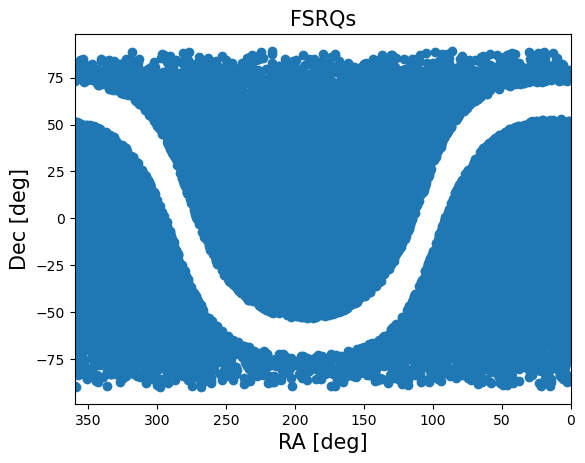

In [24]:
plt.scatter(fsrq_rands[:, 0], fsrq_rands[:, 1])
plt.title('FSRQs', fontsize = 15)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

(360.0, 0.0)

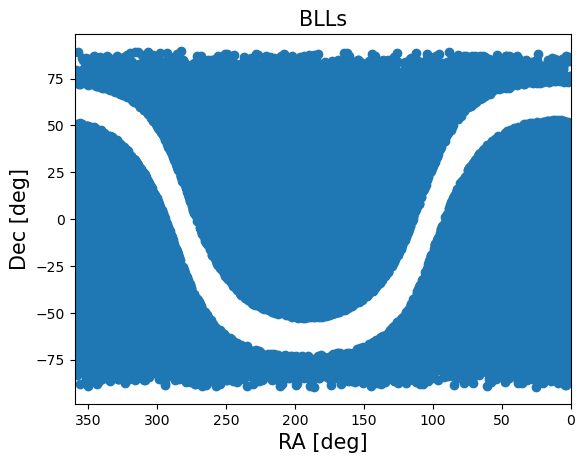

In [25]:
plt.scatter(bll_rands[:, 0], bll_rands[:, 1])
plt.title('BLLs', fontsize = 15)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

In [3]:
from compute_wtheta import compute_wtheta

In [4]:
new_wtheta_fsrq = compute_wtheta('4LAC_DR3_FSRQ.fits', 'good_fsrq_randoms.npy', 20)

In [8]:
new_wtheta_bll = compute_wtheta('4LAC_DR3_BLL.fits', 'good_bll_randoms.npy', 20)

In [9]:
new_fsrq_arr = wtheta_dvecs(new_wtheta_fsrq)
new_bll_arr = wtheta_dvecs(new_wtheta_bll)

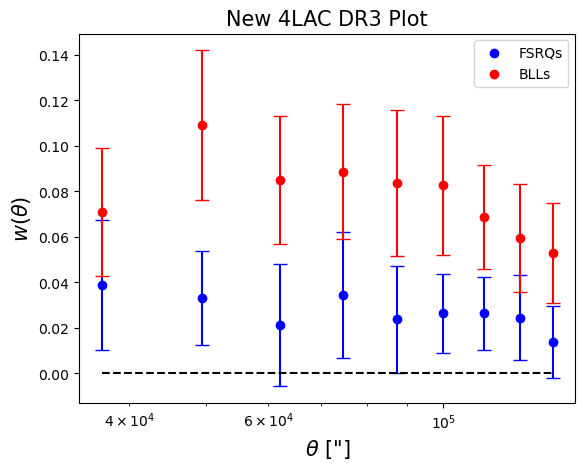

In [11]:
plt.scatter(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1], yerr = new_fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1], color = 'red', label = 'BLLs')
plt.errorbar(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1], yerr = new_bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.hlines(0, min(new_fsrq_arr[:, 0] * 3600), max(new_fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('New 4LAC DR3 Plot', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')

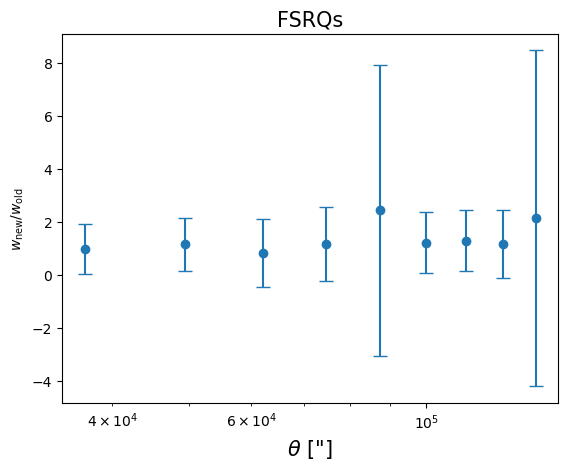

In [23]:
err = abs(new_fsrq_arr[:, 1] / fsrq_arr[:, 1]) * np.sqrt(((new_fsrq_arr[:, -1] / new_fsrq_arr[:, 1]) ** 2) + ((fsrq_arr[:, -1] / fsrq_arr[:, 1]) ** 2))
plt.scatter(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1] / fsrq_arr[:, 1])
plt.errorbar(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1] / fsrq_arr[:, 1], err, linestyle = '', capsize = 5)
plt.title('FSRQs', fontsize = 15)
plt.ylabel(r'$w_{\mathrm{new}}/w_{\mathrm{old}}$')
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.xscale('log')

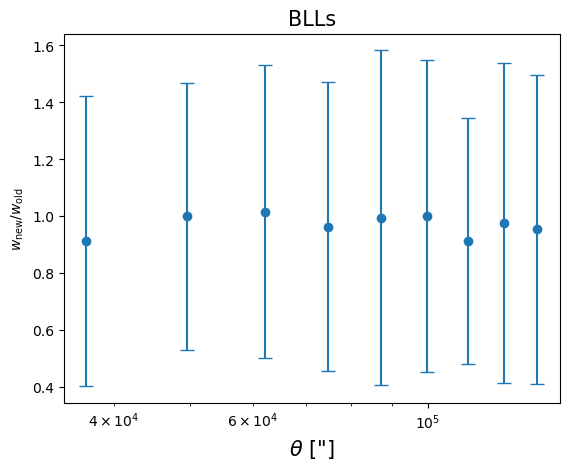

In [24]:
err = abs(new_bll_arr[:, 1] / bll_arr[:, 1]) * np.sqrt(((new_bll_arr[:, -1] / new_bll_arr[:, 1]) ** 2) + ((bll_arr[:, -1] / bll_arr[:, 1]) ** 2))
plt.scatter(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1] / bll_arr[:, 1])
plt.errorbar(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1] / bll_arr[:, 1], err, linestyle = '', capsize = 5)
plt.title('BLLs', fontsize = 15)
plt.ylabel(r'$w_{\mathrm{new}}/w_{\mathrm{old}}$')
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.xscale('log')